In [1]:
import numpy as np

results_files = np.array([
    [
        ['../output/2-agents_domain-Matrix-IPD_drift-identity_DRIVE-TD_2026-04-12-12-57-40/results.json'],
        ['../output/2-agents_domain-Matrix-IPD_drift-identity_DRIVE-TD-UNSTABLE-COMMUNICATION_2026-04-12-12-57-53/results.json'],
    ],
    [
        ['../output/2-agents_domain-CoinGame-2_drift-identity_DRIVE-TD_2026-04-12-22-01-34/results.json'],
        ['../output/2-agents_domain-CoinGame-2_drift-identity_DRIVE-TD-UNSTABLE-COMMUNICATION_2026-04-12-22-01-34/results.json'],
    ],
    [
        ['../output/4-agents_domain-CoinGame-4_drift-identity_DRIVE-TD_2026-04-12-22-01-34/results.json'],
        ['../output/4-agents_domain-CoinGame-4_drift-identity_DRIVE-TD-UNSTABLE-COMMUNICATION_2026-04-12-22-01-34/results.json']
    ],
    [
        ['../output/12-agents_domain-Harvest-12_drift-identity_DRIVE-TD_2026-04-12-22-01-34/results.json'],
        ['../output/12-agents_domain-Harvest-12_drift-identity_DRIVE-TD-UNSTABLE-COMMUNICATION_2026-04-12-22-01-34/results.json']
    ]
], dtype=str)

In [2]:
results_files.shape

(4, 2, 1)

In [3]:
import json

def load_json(p: str):
    with open(p) as f:
        return json.load(f)

json_data = np.vectorize(load_json)(results_files)

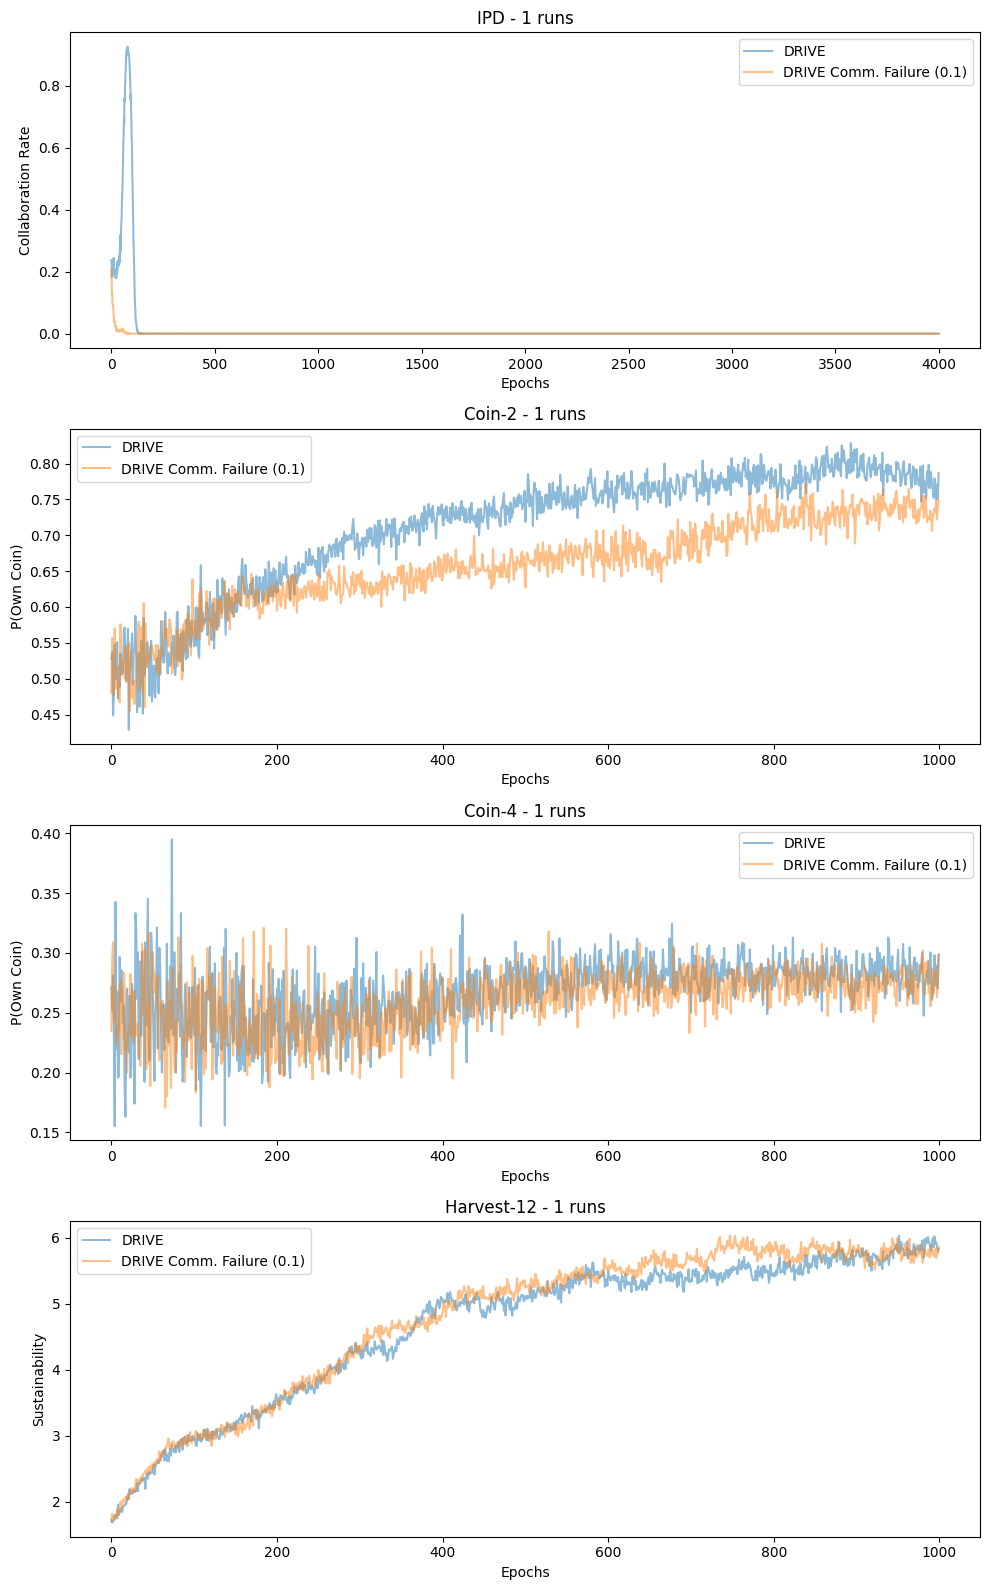

In [20]:
from datetime import datetime
from matplotlib import pyplot as plt

def collaboration_rate(domain_values: np.ndarray):
    return 'Collaboration Rate', domain_values[..., 1].mean(axis=0) / (domain_values[..., 0].mean(axis=0) * 1.0)

def own_coin_rate(domain_values: np.ndarray):
    return 'P(Own Coin)', domain_values[..., 2].mean(axis=0) / domain_values[..., 1].mean(axis=0)

def sustainability(domain_values: np.ndarray):
    return 'Sustainability', domain_values[..., 3].mean(axis=0) / (domain_values[..., 0].mean(axis=0) * 1.0)

game_names = ['IPD', 'Coin-2', 'Coin-4', 'Harvest-12']
domain_value_metric_functions = [collaboration_rate, own_coin_rate, own_coin_rate, sustainability]
algo_names = ['DRIVE', 'DRIVE Comm. Failure (0.1)']

fig, axs = plt.subplots(json_data.shape[0], 1, figsize=[10, 16])
for i, (game_name, data, fun) in enumerate(zip(game_names, json_data, domain_value_metric_functions)):
    ax = axs[i]
    for j, (algo_name, d) in enumerate(zip(algo_names, data)):
        domain_values = np.array([x['domain_values'] for x in d])
        metric_name, mean_domain_values = fun(domain_values)

        ax.plot(list(range(len(mean_domain_values))), mean_domain_values, alpha=0.5, label=algo_name)
        ax.set_title(f'{game_name} - {domain_values.shape[0]} runs')
        ax.set_ylabel(metric_name)
        ax.set_xlabel('Epochs')
        ax.legend()

fig.tight_layout()
plt.savefig(f'plots/performance_summary_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.png')
